# 🏥 SmartCare Guardian
## Routine Suggestion Engine — Model Training

**Project:** SmartCare Guardian — Predictive AI for Elderly Care  
**Purpose:** Train ML models that suggest routine changes/additions for elderly residents  
**Dataset:** `dataset/routine_suggestion_dataset.csv` (generated by `generate_dataset.py`)

---
### What this notebook does:
1. Load & explore the dataset
2. Preprocess features
3. Train one model per suggestion target (15 targets)
4. Evaluate each model with accuracy, precision, recall
5. Save all models to the `models/` folder
---

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Create models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

print('✅ Libraries imported successfully')
print(f'   pandas   : {pd.__version__}')
print(f'   numpy    : {np.__version__}')
print(f'   sklearn  : installed')

✅ Libraries imported successfully
   pandas   : 2.3.3
   numpy    : 2.4.1
   sklearn  : installed


## Step 2 — Load the Dataset

In [2]:
# Load the dataset generated by generate_dataset.py
df = pd.read_csv('dataset/routine_suggestion_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {len(df)}  |  Columns: {len(df.columns)}')
print()
df.head()

Dataset shape: (500, 42)
Rows: 500  |  Columns: 42



,resident_id,gender,dob,age,medical_conditions,dietary_restrictions,allergies,blood_pressure_systolic,blood_pressure_diastolic,blood_sugar,...,add_exercise_routine,change_checkup_routine,checkup_frequency,add_checkup_routine,add_hygiene_routine,change_hygiene_routine,hygiene_assistance_level,add_therapy_routine,change_therapy_routine,therapy_type_suggestion
0,1,Male,1963-11-04,62,"Hypertension, Type 2 Diabetes, High Cholesterol",NaN,No known allergies,141.8,89.9,100.8,...,1,0,weekly,1,0,0,0,0,0,0
1,2,Male,1942-06-21,83,"Heart Disease, Obesity, High Cholesterol",NaN,No known allergies,113.8,69.0,126.8,...,0,0,weekly,0,0,1,1,1,0,2
2,3,Male,1936-10-08,89,"Type 2 Diabetes, Arthritis",NaN,Shellfish,125.4,77.1,128.5,...,0,0,monthly,1,1,0,2,1,0,1
3,4,Female,1952-10-25,73,"Hypertension, Obesity",Low sodium,No known allergies,107.8,67.8,93.3,...,0,0,monthly,0,0,0,0,0,0,0
4,5,Female,1936-03-05,89,"Type 2 Diabetes, Arthritis, Osteoporosis, Obes...",Soft food diet,Shellfish,130.7,77.2,146.1,...,1,0,weekly,0,0,1,2,1,0,1


In [3]:
# Check column names and data types
print('Column names and types:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())

Column names and types:
resident_id                   int64
gender                       object
dob                          object
age                           int64
medical_conditions           object
dietary_restrictions         object
allergies                    object
blood_pressure_systolic     float64
blood_pressure_diastolic    float64
blood_sugar                 float64
pulse                       float64
weight                      float64
temperature                 float64
oxygen_saturation           float64
has_hypertension              int64
has_diabetes                  int64
has_heart_disease             int64
has_arthritis                 int64
has_osteoporosis              int64
has_obesity                   int64
is_low_sodium_diet            int64
is_diabetic_diet              int64
has_meal_routine              int64
has_exercise_routine          int64
has_checkup_routine           int64
has_hygiene_routine           int64
has_therapy_routine           int64
chan

In [4]:
# Basic statistics for the vital signs
vitals = ['blood_pressure_systolic', 'blood_pressure_diastolic',
          'blood_sugar', 'pulse', 'weight', 'temperature', 'oxygen_saturation']

print('=== Vital Signs Statistics ===')
df[vitals].describe().round(2)

=== Vital Signs Statistics ===


,blood_pressure_systolic,blood_pressure_diastolic,blood_sugar,pulse,weight,temperature,oxygen_saturation
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,132.19,82.14,118.98,76.42,68.03,36.70,97.01
std,17.71,11.58,28.67,10.33,14.75,0.43,1.44
min,90.00,55.00,60.00,47.90,38.00,35.50,92.00
25%,119.55,73.97,97.28,68.80,57.18,36.40,96.10
50%,132.15,82.20,119.50,76.50,68.30,36.70,97.05
75%,145.40,90.80,139.80,83.60,78.53,37.00,98.00
max,177.60,113.40,199.10,110.00,114.30,38.00,100.00


## Step 3 — Exploratory Data Analysis (EDA)

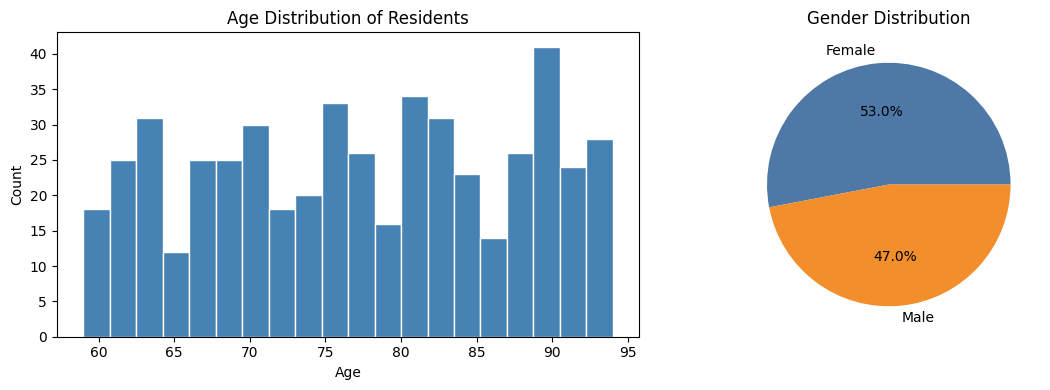

Chart saved → visualizations/eda_demographics.png


In [20]:
# Age and gender distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution of Residents')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

gender_counts = df['gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#4e79a7','#f28e2b'])
axes[1].set_title('Gender Distribution')

plt.tight_layout()
plt.savefig('visualizations/eda_demographics.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved → visualizations/eda_demographics.png')

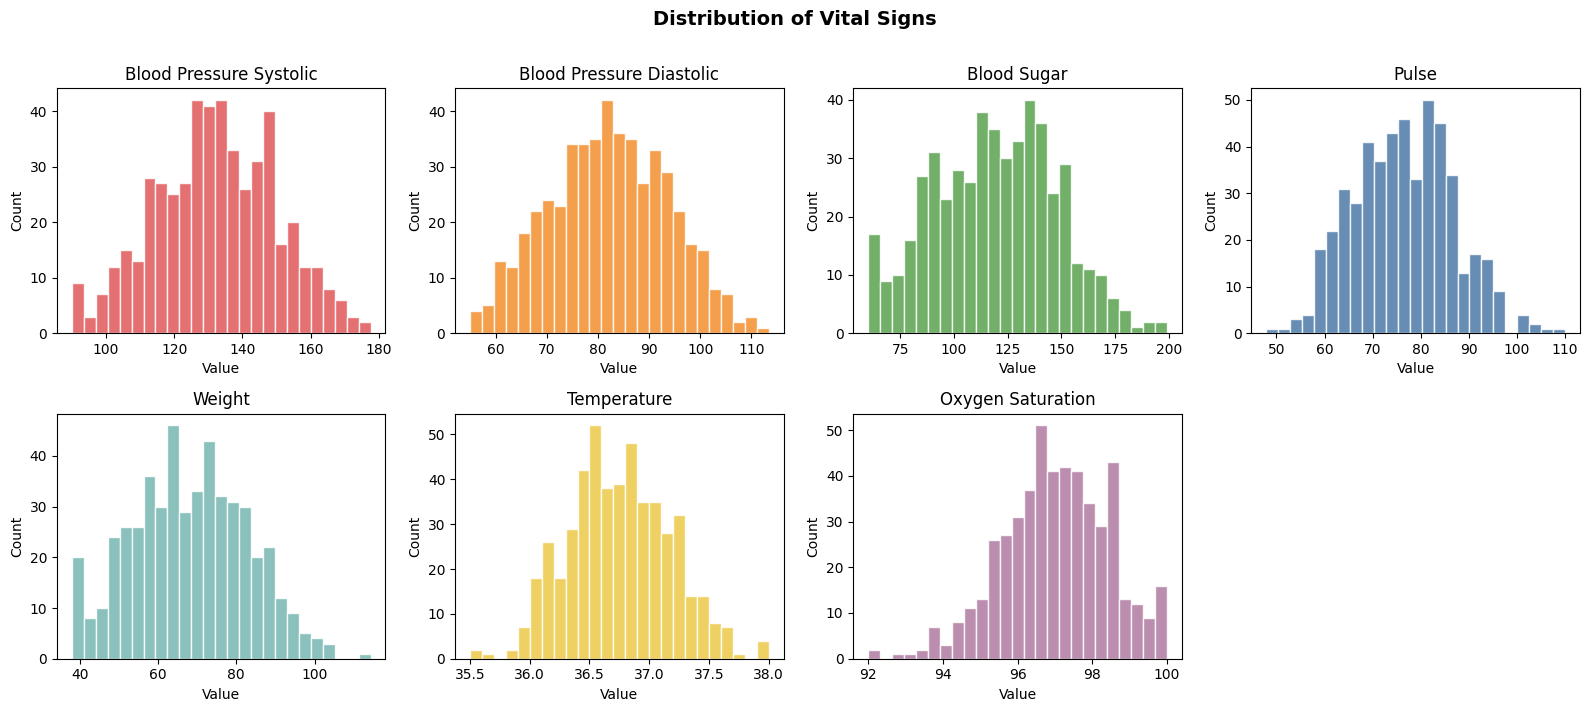

Chart saved → visualizations/eda_vitals.png


In [21]:
# Vital signs distribution
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

colors = ['#e15759','#f28e2b','#59a14f','#4e79a7','#76b7b2','#edc948','#b07aa1']

for idx, col in enumerate(vitals):
    axes[idx].hist(df[col], bins=25, color=colors[idx], edgecolor='white', alpha=0.85)
    axes[idx].set_title(col.replace('_', ' ').title())
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Count')

axes[-1].axis('off')  # hide empty subplot
fig.suptitle('Distribution of Vital Signs', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('visualizations/eda_vitals.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved → visualizations/eda_vitals.png')

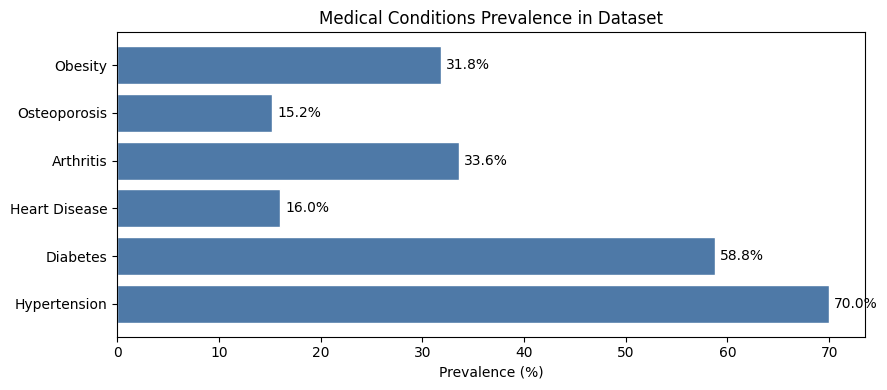

In [22]:
# Medical conditions prevalence
condition_cols = ['has_hypertension','has_diabetes','has_heart_disease',
                  'has_arthritis','has_osteoporosis','has_obesity']

prevalence = df[condition_cols].mean() * 100
prevalence.index = [c.replace('has_','').replace('_',' ').title() for c in prevalence.index]

plt.figure(figsize=(9, 4))
bars = plt.barh(prevalence.index, prevalence.values, color='#4e79a7', edgecolor='white')
for bar, val in zip(bars, prevalence.values):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)
plt.xlabel('Prevalence (%)')
plt.title('Medical Conditions Prevalence in Dataset')
plt.tight_layout()
plt.savefig('visualizations/eda_conditions.png', dpi=100, bbox_inches='tight')
plt.show()

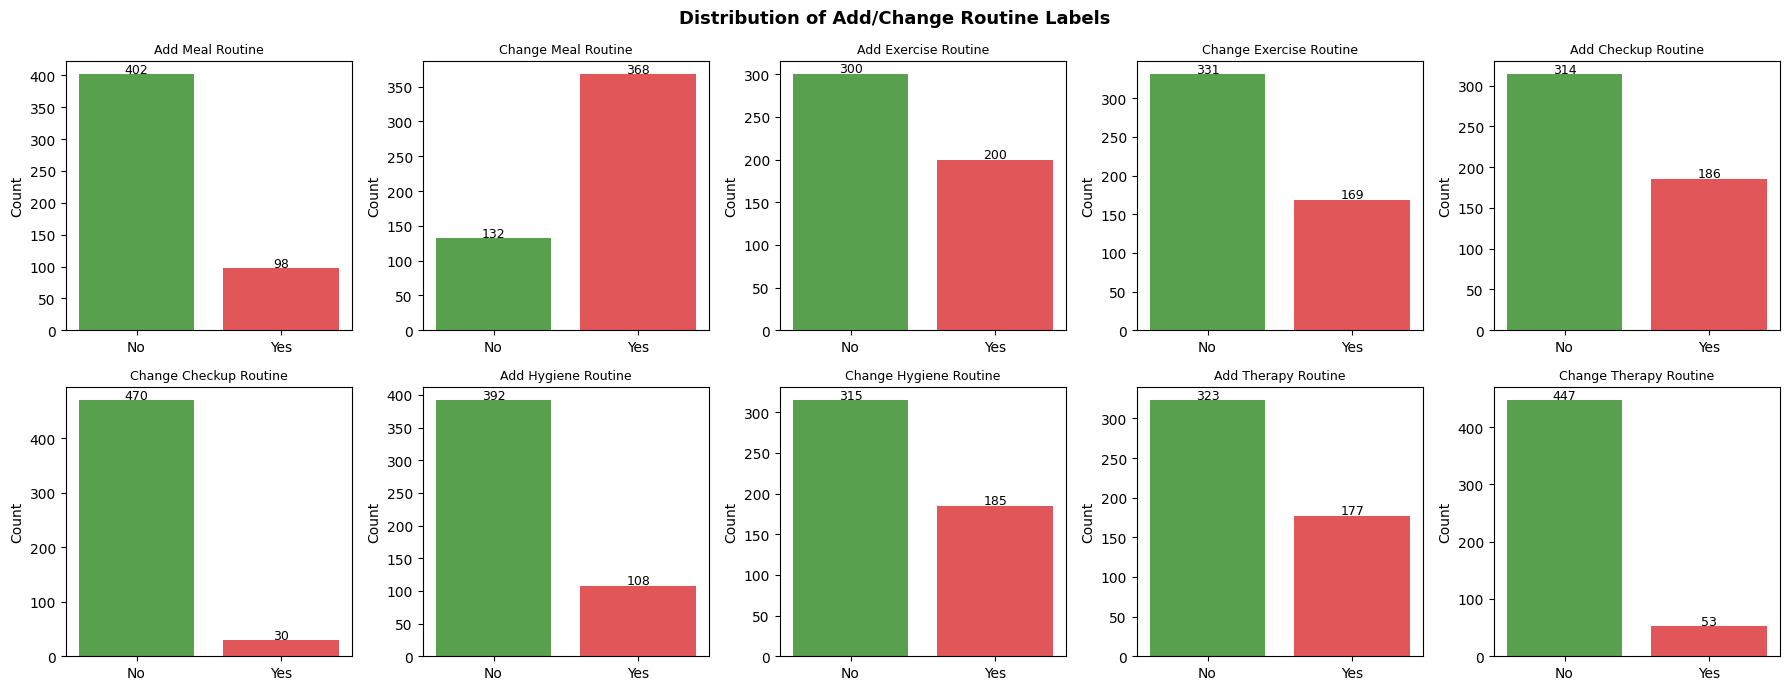

In [23]:
# Label distribution — what the AI will predict
label_cols = [
    'add_meal_routine','change_meal_routine',
    'add_exercise_routine','change_exercise_routine',
    'add_checkup_routine','change_checkup_routine',
    'add_hygiene_routine','change_hygiene_routine',
    'add_therapy_routine','change_therapy_routine'
]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for idx, col in enumerate(label_cols):
    counts = df[col].value_counts().sort_index()
    labels_map = {0: 'No', 1: 'Yes'}
    axes[idx].bar(
        [labels_map.get(k, str(k)) for k in counts.index],
        counts.values,
        color=['#59a14f','#e15759']
    )
    axes[idx].set_title(col.replace('_',' ').title(), fontsize=9)
    axes[idx].set_ylabel('Count')
    for i, v in enumerate(counts.values):
        axes[idx].text(i, v + 2, str(v), ha='center', fontsize=9)

fig.suptitle('Distribution of Add/Change Routine Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/eda_labels.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 4 — Preprocessing

In [9]:
# ── Encode gender (Male=0, Female=1) ──────────────────────────────
le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])

# ── Encode checkup_frequency (monthly=0, weekly=1, daily=2) ───────
freq_map = {'monthly': 0, 'weekly': 1, 'daily': 2}
df['checkup_frequency_encoded'] = df['checkup_frequency'].map(freq_map)

print('Gender encoding:', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print('Checkup frequency encoding:', freq_map)

# ── Save encoders for use in prediction later ──────────────────────
joblib.dump(le_gender, 'models/le_gender.pkl')
joblib.dump(freq_map,  'models/freq_map.pkl')
print('\n✅ Encoders saved to models/')

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}
Checkup frequency encoding: {'monthly': 0, 'weekly': 1, 'daily': 2}

✅ Encoders saved to models/


In [10]:
# ── Define feature columns (inputs to all models) ─────────────────
FEATURE_COLS = [
    # Demographics
    'age',
    'gender_encoded',
    # Vitals
    'blood_pressure_systolic',
    'blood_pressure_diastolic',
    'blood_sugar',
    'pulse',
    'weight',
    'temperature',
    'oxygen_saturation',
    # Conditions
    'has_hypertension',
    'has_diabetes',
    'has_heart_disease',
    'has_arthritis',
    'has_osteoporosis',
    'has_obesity',
    'is_low_sodium_diet',
    'is_diabetic_diet',
    # Existing routines
    'has_meal_routine',
    'has_exercise_routine',
    'has_checkup_routine',
    'has_hygiene_routine',
    'has_therapy_routine',
]

# ── Define all targets the AI will predict ──────────────────────────
TARGETS = {
    # Binary targets (0 or 1)
    'add_meal_routine'        : 'binary',
    'change_meal_routine'     : 'binary',
    'add_exercise_routine'    : 'binary',
    'change_exercise_routine' : 'binary',
    'add_checkup_routine'     : 'binary',
    'change_checkup_routine'  : 'binary',
    'add_hygiene_routine'     : 'binary',
    'change_hygiene_routine'  : 'binary',
    'add_therapy_routine'     : 'binary',
    'change_therapy_routine'  : 'binary',
    # Multi-class targets
    'meal_type_suggestion'        : 'multiclass',
    'exercise_intensity'          : 'multiclass',
    'hygiene_assistance_level'    : 'multiclass',
    'therapy_type_suggestion'     : 'multiclass',
    'checkup_frequency_encoded'   : 'multiclass',
}

X = df[FEATURE_COLS]
print(f'Feature matrix shape: {X.shape}')
print(f'Number of targets to train: {len(TARGETS)}')
print()
print('Features:')
for f in FEATURE_COLS:
    print(f'  {f}')

# Save feature list for use in prediction script
joblib.dump(FEATURE_COLS, 'models/feature_cols.pkl')
print('\n✅ Feature list saved to models/feature_cols.pkl')

Feature matrix shape: (500, 22)
Number of targets to train: 15

Features:
  age
  gender_encoded
  blood_pressure_systolic
  blood_pressure_diastolic
  blood_sugar
  pulse
  weight
  temperature
  oxygen_saturation
  has_hypertension
  has_diabetes
  has_heart_disease
  has_arthritis
  has_osteoporosis
  has_obesity
  is_low_sodium_diet
  is_diabetic_diet
  has_meal_routine
  has_exercise_routine
  has_checkup_routine
  has_hygiene_routine
  has_therapy_routine

✅ Feature list saved to models/feature_cols.pkl


## Step 5 — Train Models

In [11]:
# ── Train one Random Forest model per target ───────────────────────
# Random Forest is ideal here because:
#   - Handles mixed numeric + binary features well
#   - Works on small datasets without overfitting
#   - Gives feature importance scores
#   - No need for feature scaling

results = {}   # store accuracy scores
models  = {}   # store trained models

print('Training models...\n')
print(f'{"Target":<35} {"Type":<12} {"Accuracy":>10} {"CV Score":>10}')
print('-' * 70)

for target, kind in TARGETS.items():
    y = df[target]

    # Train/test split — 80% train, 20% test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42,
        stratify=y if y.nunique() > 1 else None
    )

    # Random Forest with balanced class weights
    model = RandomForestClassifier(
        n_estimators   = 150,
        max_depth      = 10,
        min_samples_leaf = 2,
        class_weight   = 'balanced',
        random_state   = 42,
        n_jobs         = -1
    )
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # 5-fold cross validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()

    print(f'{target:<35} {kind:<12} {acc:>9.2%} {cv_mean:>9.2%}')

    models[target]  = model
    results[target] = {'accuracy': acc, 'cv_score': cv_mean, 'type': kind}

print('-' * 70)
avg_acc = np.mean([r['accuracy'] for r in results.values()])
print(f'{"AVERAGE":<35} {"":<12} {avg_acc:>9.2%}')
print(f'\n✅ All {len(models)} models trained successfully')

Training models...

Target                              Type           Accuracy   CV Score
----------------------------------------------------------------------
add_meal_routine                    binary          98.00%    98.60%
change_meal_routine                 binary          98.00%    99.00%
add_exercise_routine                binary         100.00%    99.60%
change_exercise_routine             binary          99.00%    98.40%
add_checkup_routine                 binary          98.00%    98.40%
change_checkup_routine              binary          95.00%    95.80%
add_hygiene_routine                 binary         100.00%    99.40%
change_hygiene_routine              binary         100.00%    98.80%
add_therapy_routine                 binary          99.00%    98.60%
change_therapy_routine              binary          98.00%    96.60%
meal_type_suggestion                multiclass      97.00%    98.00%
exercise_intensity                  multiclass      95.00%    96.20%
hygiene_as

## Step 6 — Evaluate Models in Detail

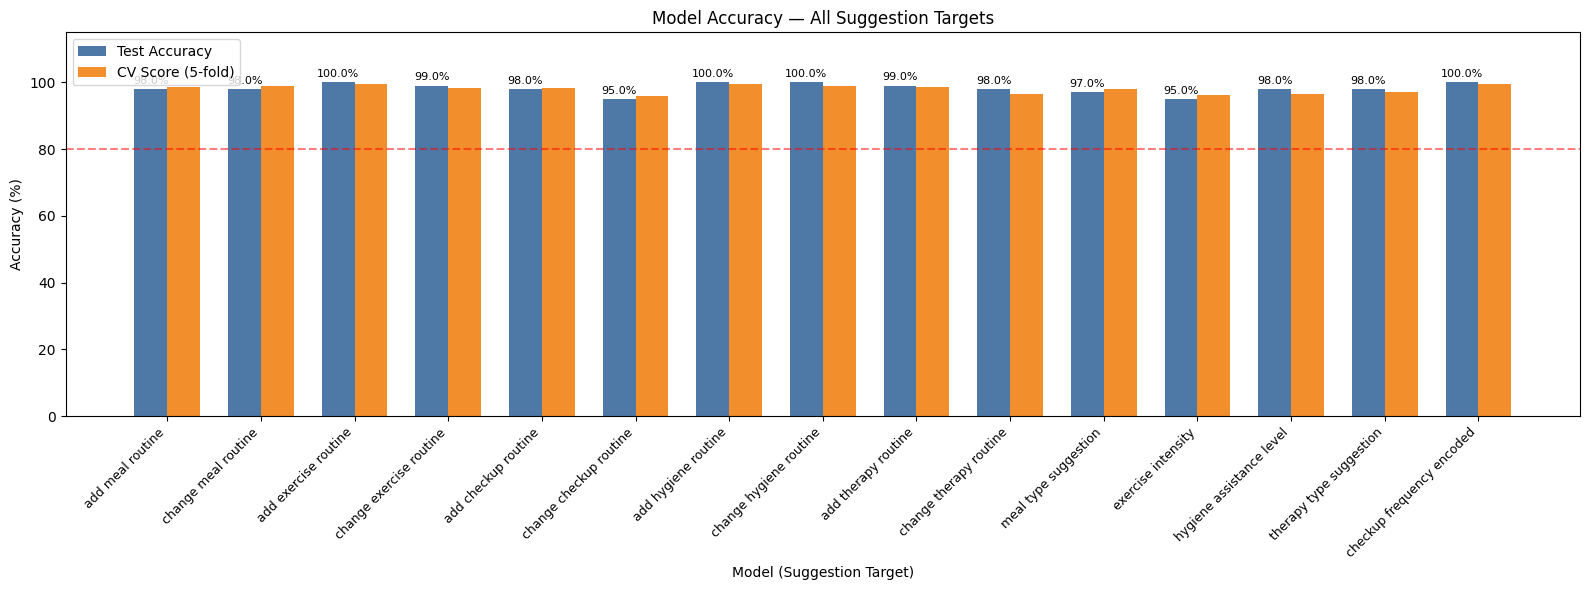

Chart saved → visualizations/model_accuracy.png


In [24]:
# ── Accuracy bar chart for all models ─────────────────────────────
names = list(results.keys())
accs  = [results[n]['accuracy'] * 100 for n in names]
cvs   = [results[n]['cv_score']  * 100 for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width/2, accs, width, label='Test Accuracy',  color='#4e79a7')
bars2 = ax.bar(x + width/2, cvs,  width, label='CV Score (5-fold)', color='#f28e2b')

ax.set_xlabel('Model (Suggestion Target)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy — All Suggestion Targets')
ax.set_xticks(x)
ax.set_xticklabels([n.replace('_',' ') for n in names], rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 115)
ax.legend()
ax.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% threshold')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('visualizations/model_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved → visualizations/model_accuracy.png')

In [13]:
# ── Detailed classification report for key models ─────────────────
key_targets = ['exercise_intensity', 'meal_type_suggestion', 'therapy_type_suggestion']

for target in key_targets:
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42,
        stratify=y if y.nunique() > 1 else None
    )
    y_pred = models[target].predict(X_test)

    print(f'\n=== {target.replace("_"," ").upper()} ===')
    print(classification_report(y_test, y_pred, zero_division=0))


=== EXERCISE INTENSITY ===
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        19
           1       0.91      1.00      0.95        51
           2       1.00      1.00      1.00        21
           3       1.00      0.89      0.94         9

    accuracy                           0.95       100
   macro avg       0.98      0.92      0.94       100
weighted avg       0.95      0.95      0.95       100


=== MEAL TYPE SUGGESTION ===
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       1.00      1.00      1.00        62
           2       1.00      1.00      1.00        19
           3       1.00      1.00      1.00         8
           4       0.80      1.00      0.89         4
           5       0.50      0.33      0.40         3

    accuracy                           0.97       100
   macro avg       0.84      0.85      0.84       100
weighted avg       

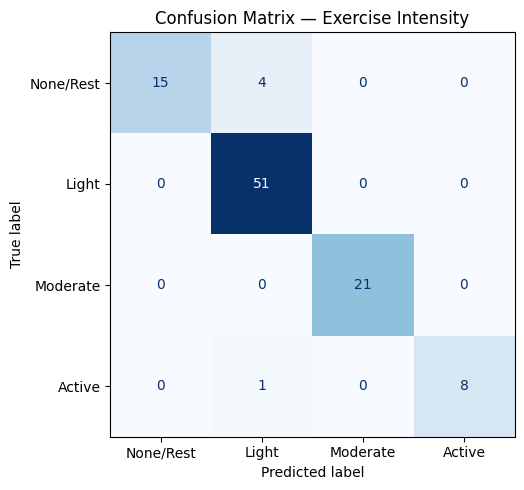

In [25]:
# ── Confusion matrix for exercise_intensity ────────────────────────
target = 'exercise_intensity'
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_pred = models[target].predict(X_test)

labels_map = {0: 'None/Rest', 1: 'Light', 2: 'Moderate', 3: 'Active'}
class_names = [labels_map[c] for c in sorted(y.unique())]

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Exercise Intensity')
plt.tight_layout()
plt.savefig('visualizations/confusion_exercise.png', dpi=100, bbox_inches='tight')
plt.show()

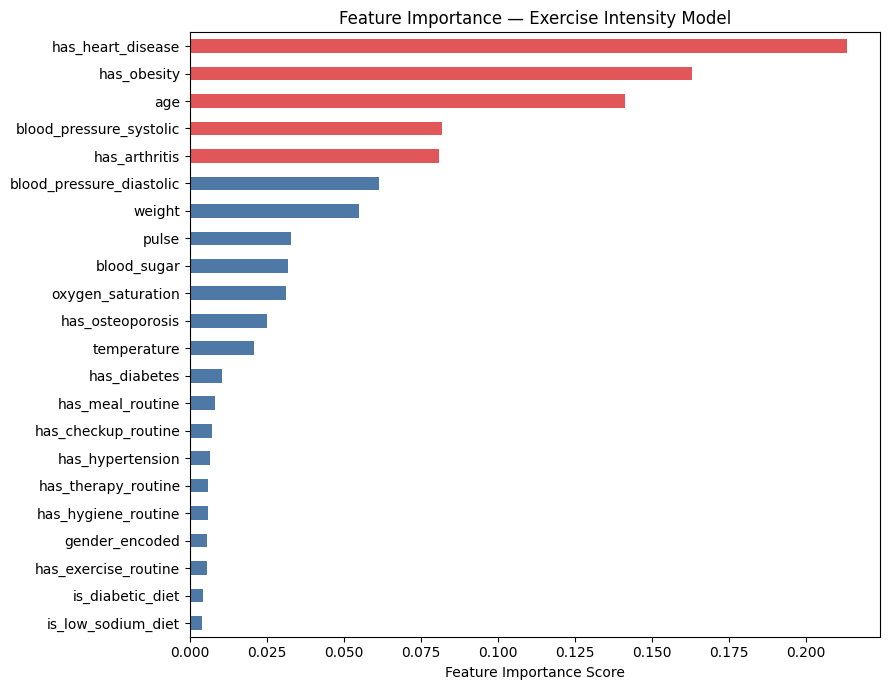

Most important features (top 5):
has_heart_disease          0.213342
has_obesity                0.162812
age                        0.141050
blood_pressure_systolic    0.081740
has_arthritis              0.080692
dtype: float64


In [26]:
# ── Feature importance — which inputs matter most? ─────────────────
# Using exercise_intensity as the example model

importance_model = models['exercise_intensity']
importances = importance_model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
colors_imp = ['#e15759' if v > 0.08 else '#4e79a7' for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors_imp)
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance — Exercise Intensity Model')
plt.tight_layout()
plt.savefig('visualizations/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print('Most important features (top 5):')
print(feat_imp.sort_values(ascending=False).head(5))

## Step 7 — Save All Models

In [16]:
# ── Save every trained model as a .pkl file ────────────────────────
print('Saving models...\n')

for target, model in models.items():
    path = f'models/model_{target}.pkl'
    joblib.dump(model, path)
    print(f'  ✅ Saved: {path}')

# Also save all models in one file (convenient for the API)
joblib.dump(models, 'models/all_models.pkl')
print('\n  ✅ Saved: models/all_models.pkl  (all models in one file)')

print('\n✅ All models saved to models/ folder')

Saving models...

  ✅ Saved: models/model_add_meal_routine.pkl
  ✅ Saved: models/model_change_meal_routine.pkl
  ✅ Saved: models/model_add_exercise_routine.pkl
  ✅ Saved: models/model_change_exercise_routine.pkl
  ✅ Saved: models/model_add_checkup_routine.pkl
  ✅ Saved: models/model_change_checkup_routine.pkl
  ✅ Saved: models/model_add_hygiene_routine.pkl
  ✅ Saved: models/model_change_hygiene_routine.pkl
  ✅ Saved: models/model_add_therapy_routine.pkl
  ✅ Saved: models/model_change_therapy_routine.pkl
  ✅ Saved: models/model_meal_type_suggestion.pkl
  ✅ Saved: models/model_exercise_intensity.pkl
  ✅ Saved: models/model_hygiene_assistance_level.pkl
  ✅ Saved: models/model_therapy_type_suggestion.pkl
  ✅ Saved: models/model_checkup_frequency_encoded.pkl

  ✅ Saved: models/all_models.pkl  (all models in one file)

✅ All models saved to models/ folder


In [17]:
# ── Verify saved files ─────────────────────────────────────────────
import os
saved_files = os.listdir('models/')
print(f'Files saved in models/ folder ({len(saved_files)} total):\n')
for f in sorted(saved_files):
    size_kb = os.path.getsize(f'models/{f}') / 1024
    print(f'  {f:<45} {size_kb:>8.1f} KB')

Files saved in models/ folder (26 total):

  all_models.pkl                                 14248.1 KB
  confusion_exercise.png                            19.4 KB
  eda_conditions.png                                23.4 KB
  eda_demographics.png                              25.5 KB
  eda_labels.png                                    67.8 KB
  eda_vitals.png                                    52.5 KB
  feature_cols.pkl                                   0.4 KB
  feature_importance.png                            49.3 KB
  freq_map.pkl                                       0.0 KB
  le_gender.pkl                                      0.5 KB
  model_accuracy.png                                72.3 KB
  model_add_checkup_routine.pkl                    741.7 KB
  model_add_exercise_routine.pkl                   744.1 KB
  model_add_hygiene_routine.pkl                    635.0 KB
  model_add_meal_routine.pkl                       659.5 KB
  model_add_therapy_routine.pkl                    878.0 

## Step 8 — Test a Sample Prediction

In [18]:
# ── Simulate predicting suggestions for one resident ───────────────
# This is exactly what the Flask API will do when called from PHP

# Load saved models and encoders
loaded_models   = joblib.load('models/all_models.pkl')
loaded_features = joblib.load('models/feature_cols.pkl')
loaded_gender   = joblib.load('models/le_gender.pkl')

# --- Simulated resident data (replace with real DB values) ---
sample_resident = {
    'age'                       : 76,
    'gender'                    : 'Female',
    'blood_pressure_systolic'   : 155.0,
    'blood_pressure_diastolic'  : 95.0,
    'blood_sugar'               : 162.0,
    'pulse'                     : 84.0,
    'weight'                    : 72.0,
    'temperature'               : 36.8,
    'oxygen_saturation'         : 96.5,
    'has_hypertension'          : 1,
    'has_diabetes'              : 1,
    'has_heart_disease'         : 0,
    'has_arthritis'             : 1,
    'has_osteoporosis'          : 0,
    'has_obesity'               : 0,
    'is_low_sodium_diet'        : 0,
    'is_diabetic_diet'          : 0,
    'has_meal_routine'          : 1,
    'has_exercise_routine'      : 1,
    'has_checkup_routine'       : 0,
    'has_hygiene_routine'       : 1,
    'has_therapy_routine'       : 0,
}

# Encode gender
sample_resident['gender_encoded'] = int(
    loaded_gender.transform([sample_resident['gender']])[0]
)

# Build feature vector in correct order
X_sample = pd.DataFrame([sample_resident])[loaded_features]

print('=== Sample Resident ===')
print(f"  Age: {sample_resident['age']} | Gender: {sample_resident['gender']}")
print(f"  BP: {sample_resident['blood_pressure_systolic']}/{sample_resident['blood_pressure_diastolic']}")
print(f"  Blood Sugar: {sample_resident['blood_sugar']} | Pulse: {sample_resident['pulse']}")
print(f"  Conditions: Hypertension={sample_resident['has_hypertension']}, "
      f"Diabetes={sample_resident['has_diabetes']}, Arthritis={sample_resident['has_arthritis']}")
print()

# Label maps
MEAL_TYPES = {0:'Standard diet', 1:'Low-sodium diet', 2:'Diabetic diet',
              3:'Low-sodium + Diabetic', 4:'Weight-loss diet', 5:'Soft food diet'}
EXERCISE   = {0:'No exercise — rest only', 1:'Light (gentle walk, chair yoga)',
              2:'Moderate (30 min daily)', 3:'Active (brisk walk, resistance)'}
HYGIENE    = {0:'Independent', 1:'Supervised', 2:'Needs assistance'}
THERAPY    = {0:'None needed', 1:'Physiotherapy', 2:'Breathing exercises',
              3:'Relaxation/stress therapy', 4:'Occupational therapy'}
CHECKUP    = {0:'Monthly', 1:'Weekly', 2:'Daily'}

print('=== AI Routine Suggestions ===')
print()

for target, model in loaded_models.items():
    pred = model.predict(X_sample)[0]
    conf = max(model.predict_proba(X_sample)[0])

    # Human-readable label
    if target == 'meal_type_suggestion':       label = MEAL_TYPES.get(pred, pred)
    elif target == 'exercise_intensity':       label = EXERCISE.get(pred, pred)
    elif target == 'hygiene_assistance_level': label = HYGIENE.get(pred, pred)
    elif target == 'therapy_type_suggestion':  label = THERAPY.get(pred, pred)
    elif target == 'checkup_frequency_encoded':label = CHECKUP.get(pred, pred)
    elif pred == 1:                            label = '⚠️  YES — Recommended'
    else:                                      label = '✓  No change needed'

    print(f'  {target.replace("_"," "):<35} → {label}  ({conf:.0%} confidence)')

=== Sample Resident ===
  Age: 76 | Gender: Female
  BP: 155.0/95.0
  Blood Sugar: 162.0 | Pulse: 84.0
  Conditions: Hypertension=1, Diabetes=1, Arthritis=1

=== AI Routine Suggestions ===

  add meal routine                    → ✓  No change needed  (95% confidence)
  change meal routine                 → ⚠️  YES — Recommended  (95% confidence)
  add exercise routine                → ✓  No change needed  (94% confidence)
  change exercise routine             → ⚠️  YES — Recommended  (89% confidence)
  add checkup routine                 → ⚠️  YES — Recommended  (88% confidence)
  change checkup routine              → ✓  No change needed  (95% confidence)
  add hygiene routine                 → ✓  No change needed  (95% confidence)
  change hygiene routine              → ⚠️  YES — Recommended  (81% confidence)
  add therapy routine                 → ⚠️  YES — Recommended  (90% confidence)
  change therapy routine              → ✓  No change needed  (90% confidence)
  meal type suggesti

## ✅ Training Complete!

Your `models/` folder now contains:

| File | Purpose |
|---|---|
| `all_models.pkl` | All 15 trained models in one file |
| `model_*.pkl` | Individual model files |
| `feature_cols.pkl` | Feature column order |
| `le_gender.pkl` | Gender label encoder |
| `freq_map.pkl` | Checkup frequency encoder |
| `eda_*.png` | Exploratory charts |
| `model_accuracy.png` | Accuracy comparison chart |
| `feature_importance.png` | Feature importance chart |

### Next Step → Build `app.py` (Flask API)
The Flask API will load these `.pkl` files and expose a `/suggest` endpoint  
that your PHP caregiver portal will call to get AI suggestions.

---
*SmartCare Guardian — S. Hasini Nethmini*